In [1]:
from tree.node import TerminalNode
import utils.constants as constants
from tree.tree import ReadTree
from tree.node import RootNode, SemanticNode, SyntacticNode
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from utils.dataset_sampling import read_dataset
from rouge_score import rouge_scorer
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
from collections import deque
import json
import re
import os
scorer = rouge_scorer.RougeScorer(['rougeL', 'rouge1'], use_stemmer=True)
smooth_fn = SmoothingFunction().method1

def read_trees_to_df(strategy: str, gen_modelId: str, dataset: str, terminal=False, long=False) -> pd.DataFrame:
    '''
    read trees from perturb strategy and generator to pandas df
    columns:
    - question_id (from tree path)
    ----- all nodes -----
    - layer
    - id
    - type
    - prompt
    - rag_closest_match
    - rag_entities
    - answers
    - wiki_title
    --- root/sem node ---
    - root_similarity_score
    - complexity_score
    - fk_score
    - dc_score
    ----- syn node ------
    - syntax_similarity_score
    ---------------------
    '''

    def extract_similarity(meta):
        if isinstance(meta, dict) and 'similarity' in meta:
            return meta['similarity']
        return 1
    long_prefix = "long_" if long else ""
    strategy_path = constants.STRATEGY_PATH_DICT[strategy]
    tree_dir_path = f"/vol/bitbucket/lst20/{long_prefix}{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/{gen_modelId.replace('/', '-')}/complete/"
    print(tree_dir_path)
    if not os.path.isdir(tree_dir_path) or not os.listdir(tree_dir_path):
        return pd.DataFrame()
    rows = []
    df = read_dataset(dataset, 1000)
    for _, row in df.iterrows():
        i = row['original_index']
        try:
            tree_path = f"{tree_dir_path}{i}_checked.pkl"
            tree = ReadTree.load_read_tree(tree_path)
            root = tree.root
            possible_answers = tree.possible_answers

            # ensure possible_answers is a Python list of strings
            if isinstance(possible_answers, str):
                try:
                    parsed = json.loads(possible_answers)
                    possible_answers = parsed if isinstance(parsed, list) else [parsed]
                except json.JSONDecodeError:
                    possible_answers = [possible_answers]
            elif not isinstance(possible_answers, list):
                possible_answers = [possible_answers]

            queue = deque([(root, 0)])  # (node, layer)
            visited = {root}
            question_id = i

            while queue:
                base_found_match = False
                rag_found_match = False
                node, layer = queue.popleft()

                # grab your two generated outputs
                if not node.answers:
                    continue
                if not terminal and isinstance(node, TerminalNode):
                    continue
                base_response = node.answers[gen_modelId]["base"].lower()
                rag_response = node.answers[gen_modelId]["base_rag"].lower()

                # initialize best-F1 trackers
                best = {k:-1 for k in [
                    'base_f1_1','base_f1_L','rag_f1_1','rag_f1_L',
                    'base_rec_1','base_rec_L','rag_rec_1','rag_rec_L',
                    'base_prec_1','base_prec_L','rag_prec_1','rag_prec_L',
                    # 'base_bleu','rag_bleu'
                ]}

                # for each gold answer, compute rouge-L
                for exp in possible_answers:
                    exp_low = str(exp).lower()
                    exp_low = re.sub(r'[^\w\s]', '', exp_low)

                    # 1) simple containment flags:
                    if exp_low in base_response:
                        base_found_match = True
                    if exp_low in rag_response:
                        rag_found_match = True
                    
                    # 2) Rouge-L F1
                    scores_b  = scorer.score(exp_low, base_response)
                    scores_br = scorer.score(exp_low, rag_response)
                    metrics = {
                        'base_f1_1':scores_b['rouge1'].fmeasure,
                        'base_f1_L':scores_b['rougeL'].fmeasure,
                        'rag_f1_1':scores_br['rouge1'].fmeasure,
                        'rag_f1_L':scores_br['rougeL'].fmeasure,
                        'base_rec_1':scores_b['rouge1'].recall,
                        'base_rec_L':scores_b['rougeL'].recall,
                        'rag_rec_1':scores_br['rouge1'].recall,
                        'rag_rec_L':scores_br['rougeL'].recall,
                        'base_prec_1':scores_b['rouge1'].precision,
                        'base_prec_L':scores_b['rougeL'].precision,
                        'rag_prec_1':scores_br['rouge1'].precision,
                        'rag_prec_L':scores_br['rougeL'].precision,
                    }
                    # BLEU
                    # metrics['base_bleu'] = sentence_bleu([exp_low.split()], base_response.split(), smoothing_function=smooth_fn)
                    # metrics['rag_bleu']  = sentence_bleu([exp_low.split()], rag_response.split(), smoothing_function=smooth_fn)

                    for k,v in metrics.items():
                        if v > best[k]:
                            best[k] = v
        
                # find gen em source
                source = getattr(node, "rag_closest_match", None)
                
                if source:                   
                    # terminal node type
                    if isinstance(node, TerminalNode):
                        para_type = node.metadata["terminal_name"]
                        recorded_layer = layer - 1
                    else:
                        para_type = "semantic"
                        recorded_layer = layer
                    node_data = {
                        "gen_modelId": gen_modelId,
                        "question_id": question_id,
                        "layer": recorded_layer,
                        "id": node.id,
                        "type": node.__class__.__name__ ,
                        "para_type": para_type,
                        "prompt": node.prompt,
                        "rag_closest_match": getattr(node, "rag_closest_match", None),
                        "rag_entities": getattr(node, "rag_entities", None),
                        "possible_answers": possible_answers,
                        "answers": node.answers,
                        "metadata": node.metadata,
                        "wiki_title": getattr(node, "wiki_title", None),
                        "rag_found_match": rag_found_match, 
                        "base_found_match": base_found_match,
                        **best
                    }

                    if isinstance(node, (RootNode, SemanticNode)):
                        node_data.update({
                            "root_similarity_score": getattr(node, "root_similarity_score", 0),
                            "complexity_score": getattr(node, "complexity_score", 0),
                            "fk_score": getattr(node, "fk_score", 0),
                            "dc_score": getattr(node, "dc_score", 0),
                        })

                    elif isinstance(node, (SyntacticNode)):
                        node_data["syntax_similarity_score"] = getattr(node, "syntax_similarity_score", None)

                    rows.append(node_data)
                
                for child in node.children:
                    if child not in visited:
                        queue.append((child, layer + 1))
                        visited.add(child)

        except FileNotFoundError:
            pass
        except Exception as e:
            print(f"Error loading tree: {e}")
    df = pd.DataFrame(rows)
    
    if df.get('metadata') is not None:
        df['similarity'] = df.get('metadata').apply(extract_similarity)
    else:
        df['similarity'] = 1
    # Convert nested dicts into a DataFrame
    base_rag_df = df['answers'].apply(lambda d: list(d.values())[0] if isinstance(d, dict) else {}).apply(pd.Series)

    # Merge back into the original DataFrame
    df = pd.concat([df, base_rag_df[['base', 'base_rag']]], axis=1)
    df = df.drop(columns=['answers'])

    return df
 
gen_models = ["google/gemma-3-12b-it", "google/gemma-3-1b-it", "mistralai/Mistral-7B-Instruct-v0.2"]
#, "mistral.mistral-7b-instruct-v0:2"
# Define base colors for models

model_colors = {
    'google/gemma-3-1b-it':'green',  # green
    'google/gemma-3-12b-it': 'blue',  # blue
    # 'mistral.mistral-7b-instruct-v0:2': 'red',  # red
    'mistralai/Mistral-7B-Instruct-v0.2': 'black',  # black
}


def agg_df(df, group_by=['gen_modelId','para_type','layer']):
    return (
        df.groupby(group_by)
          .agg(
            base_true      = ('base_found_match','sum'),
            base_false     = ('base_found_match',lambda x:(~x).sum()),
            base_pct       = ('base_found_match',lambda x:x.mean()*100),
            base_rag_true  = ('rag_found_match','sum'),
            base_rag_false = ('rag_found_match',lambda x:(~x).sum()),
            base_rag_pct   = ('rag_found_match',lambda x:x.mean()*100),
            base_f1_1      = ('base_f1_1','mean'),
            rag_f1_1       = ('rag_f1_1','mean'),
            base_f1_L      = ('base_f1_L','mean'),
            rag_f1_L       = ('rag_f1_L','mean'),
            base_rec_1     = ('base_rec_1','mean'),
            rag_rec_1      = ('rag_rec_1','mean'),
            base_rec_L     = ('base_rec_L','mean'),
            rag_rec_L      = ('rag_rec_L','mean'),
            base_prec_1    = ('base_prec_1','mean'),
            rag_prec_1     = ('rag_prec_1','mean'),
            base_prec_L    = ('base_prec_L','mean'),
            rag_prec_L     = ('rag_prec_L','mean'),
          )
          .reset_index()
    )

def darken_hex(hex_color: str, factor: float = 0.1) -> str:
    """
    Darkens a hex color by reducing its brightness (value) in HSV space.
    :param hex_color: Color string like "#RRGGBB" or "RRGGBB"
    :param factor: Fraction by which to darken (0.0-1.0)
    :return: Darkened color as "#RRGGBB"
    """
    hex_color = hex_color.lstrip('#')
    # Convert hex to RGB [0–1]
    r, g, b = [int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4)]
    # Convert to HSV, darken value
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    v = max(0.0, v * (1.0 - factor))
    # Convert back to RGB then to hex
    r_d, g_d, b_d = colorsys.hsv_to_rgb(h, s, v)
    return "#{:02x}{:02x}{:02x}".format(int(r_d * 255), int(g_d * 255), int(b_d * 255))


def plot_by_layer(
    agg_df,
    gen_models,
    title,
    terminal_comparison: list = [],
    plot_base: bool = True,
    plot: str = "percent"    # options: "percent", "f1_ROUGE_L", ..., "bleu"
):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Determine which columns to plot based on 'plot' parameter
    if plot == "f1_ROUGE_L":
        ycol_base, ycol_rag = 'base_f1_L', 'rag_f1_L'
        ylabel = 'Average Rouge-L F1 Score'
    elif plot == "f1_ROUGE_1":
        ycol_base, ycol_rag = 'base_f1_1', 'rag_f1_1'
        ylabel = 'Average Rouge-1 F1 Score'
    elif plot == "recall_ROUGE_L":
        ycol_base, ycol_rag = 'base_rec_L', 'rag_rec_L'
        ylabel = 'Average Rouge-L Recall'
    elif plot == "recall_ROUGE_1":
        ycol_base, ycol_rag = 'base_rec_1', 'rag_rec_1'
        ylabel = 'Average Rouge-1 Recall'
    elif plot == "prec_ROUGE_L":
        ycol_base, ycol_rag = 'base_prec_L', 'rag_prec_L'
        ylabel = 'Average Rouge-L Precision'
    elif plot == "prec_ROUGE_1":
        ycol_base, ycol_rag = 'base_prec_1', 'rag_prec_1'
        ylabel = 'Average Rouge-1 Precision'
    elif plot == "bleu":
        ycol_base, ycol_rag = 'base_bleu', 'rag_bleu'
        ylabel = 'Average BLEU Score'
    else:
        ycol_base, ycol_rag = 'base_pct', 'base_rag_pct'
        ylabel = 'EM Percentage (%)'

    for model in gen_models:
        dfm = agg_df.query("gen_modelId == @model and para_type == 'semantic'").copy()
        color = model_colors.get(model, 'black')
        name = model.split("/")[-1]

        # Print base and RAG scores per layer in a table
        print(f"\n{name} Scores by Layer:")
        print(dfm[['layer', ycol_base, ycol_rag]].to_string(index=False))

        # Compute RAG drop per layer
        dfm = dfm.sort_values('layer').reset_index(drop=True)
        dfm['rag_drop'] = dfm[ycol_rag].diff().fillna(0)

        print(f"\nRAG Drop per layer for {name}:")
        for _, row in dfm.iterrows():
            print(f"  Layer {row['layer']}: Drop = {row['rag_drop']:.4f}")
        

        # Plot base and base_rag
        if plot_base:
            ax.plot(dfm['layer'], dfm[ycol_base], marker='o', color=color, label=f'{name} - base')
        ax.plot(dfm['layer'], dfm[ycol_rag], marker='x', linestyle='--', color=color, label=f'{name} - base_rag')

        # Plot additional terminal comparisons if provided
        term_markers = ["d", "H", "v", "s", "p", "+", "1", "."]
        for i, term in enumerate(terminal_comparison):
            dft = agg_df.query("gen_modelId == @model and para_type == @term")
            if dft.empty:
                continue
            ax.plot(dft['layer'], dft[ycol_rag], marker=term_markers[i], linestyle='-.', color=color, label=f'{name} rag – {term}')
            ax.plot(dft['layer'], dft[ycol_base], marker=term_markers[i], linestyle=':', color=color, label=f'{name} base – {term}')
    ax.set_xlabel('Layer')
    ax.set_ylabel(ylabel)
    title_map = {
        'f1_ROUGE_L': 'Rouge-L F1', 'f1_ROUGE_1': 'Rouge-1 F1',
        'recall_ROUGE_L': 'Rouge-L Recall', 'recall_ROUGE_1': 'Rouge-1 Recall',
        'prec_ROUGE_L': 'Rouge-L Precision', 'prec_ROUGE_1': 'Rouge-1 Precision',
        'percent': 'EM', 'bleu': 'BLEU'
    }
    title_txt = title_map.get(plot, 'Accuracy')
    ax.set_title(f'{title} over Layers ({title_txt})')
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



06/08/2025 19:56:18 - INFO - 	 Using default tokenizer.


In [2]:
import utils.constants as constants
from tree.node import TerminalNode
import utils.constants as constants
from tree.tree import ReadTree
from tree.node import RootNode, SemanticNode, SyntacticNode
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from utils.dataset_sampling import read_dataset
from rouge_score import rouge_scorer
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
from collections import deque
import json
import re
import os
scorer = rouge_scorer.RougeScorer(['rougeL', 'rouge1'], use_stemmer=True)
smooth_fn = SmoothingFunction().method1

def read_trees_to_df(strategy: str, gen_modelId: str, dataset: str, terminal=False, long=False) -> pd.DataFrame:
    '''
    read trees from perturb strategy and generator to pandas df
    columns:
    - question_id (from tree path)
    ----- all nodes -----
    - layer
    - id
    - type
    - prompt
    - rag_closest_match
    - rag_entities
    - answers
    - wiki_title
    --- root/sem node ---
    - root_similarity_score
    - complexity_score
    - fk_score
    - dc_score
    ----- syn node ------
    - syntax_similarity_score
    ---------------------
    '''

    def extract_similarity(meta):
        if isinstance(meta, dict) and 'similarity' in meta:
            return meta['similarity']
        return 1
    long_prefix = "long_" if long else ""
    strategy_path = constants.STRATEGY_PATH_DICT[strategy]
    tree_dir_path = f"/vol/bitbucket/lst20/{long_prefix}{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/{gen_modelId.replace('/', '-')}/complete/"
    print(tree_dir_path)
    if not os.path.isdir(tree_dir_path) or not os.listdir(tree_dir_path):
        return pd.DataFrame()
    rows = []
    df = read_dataset(dataset, 1000)
    for _, row in df.iterrows():
        i = row['original_index']
        try:
            tree_path = f"{tree_dir_path}{i}_checked.pkl"
            tree = ReadTree.load_read_tree(tree_path)
            root = tree.root
            possible_answers = tree.possible_answers

            # ensure possible_answers is a Python list of strings
            if isinstance(possible_answers, str):
                try:
                    parsed = json.loads(possible_answers)
                    possible_answers = parsed if isinstance(parsed, list) else [parsed]
                except json.JSONDecodeError:
                    possible_answers = [possible_answers]
            elif not isinstance(possible_answers, list):
                possible_answers = [possible_answers]

            queue = deque([(root, 0)])  # (node, layer)
            visited = {root}
            question_id = i

            while queue:
                base_found_match = False
                rag_found_match = False
                node, layer = queue.popleft()

                # grab your two generated outputs
                if not node.answers:
                    continue
                if not terminal and isinstance(node, TerminalNode):
                    continue
                base_response = node.answers[gen_modelId]["base"].lower()
                rag_response = node.answers[gen_modelId]["base_rag"].lower()

                # initialize best-F1 trackers
                best = {k:-1 for k in [
                    'base_f1_1','base_f1_L','rag_f1_1','rag_f1_L',
                    'base_rec_1','base_rec_L','rag_rec_1','rag_rec_L',
                    'base_prec_1','base_prec_L','rag_prec_1','rag_prec_L',
                    # 'base_bleu','rag_bleu'
                ]}

                # for each gold answer, compute rouge-L
                for exp in possible_answers:
                    exp_low = str(exp).lower()
                    exp_low = re.sub(r'[^\w\s]', '', exp_low)

                    # 1) simple containment flags:
                    if exp_low in base_response:
                        base_found_match = True
                    if exp_low in rag_response:
                        rag_found_match = True
                    
                    # 2) Rouge-L F1
                    scores_b  = scorer.score(exp_low, base_response)
                    scores_br = scorer.score(exp_low, rag_response)
                    metrics = {
                        'base_f1_1':scores_b['rouge1'].fmeasure,
                        'base_f1_L':scores_b['rougeL'].fmeasure,
                        'rag_f1_1':scores_br['rouge1'].fmeasure,
                        'rag_f1_L':scores_br['rougeL'].fmeasure,
                        'base_rec_1':scores_b['rouge1'].recall,
                        'base_rec_L':scores_b['rougeL'].recall,
                        'rag_rec_1':scores_br['rouge1'].recall,
                        'rag_rec_L':scores_br['rougeL'].recall,
                        'base_prec_1':scores_b['rouge1'].precision,
                        'base_prec_L':scores_b['rougeL'].precision,
                        'rag_prec_1':scores_br['rouge1'].precision,
                        'rag_prec_L':scores_br['rougeL'].precision,
                    }
                    # BLEU
                    # metrics['base_bleu'] = sentence_bleu([exp_low.split()], base_response.split(), smoothing_function=smooth_fn)
                    # metrics['rag_bleu']  = sentence_bleu([exp_low.split()], rag_response.split(), smoothing_function=smooth_fn)

                    for k,v in metrics.items():
                        if v > best[k]:
                            best[k] = v
        
                # find gen em source
                source = getattr(node, "rag_closest_match", None)
                
                if source:                   
                    # terminal node type
                    if isinstance(node, TerminalNode):
                        para_type = node.metadata["terminal_name"]
                        recorded_layer = layer - 1
                    else:
                        para_type = "semantic"
                        recorded_layer = layer
                    node_data = {
                        "gen_modelId": gen_modelId,
                        "question_id": question_id,
                        "layer": recorded_layer,
                        "id": node.id,
                        "type": node.__class__.__name__ ,
                        "para_type": para_type,
                        "prompt": node.prompt,
                        "rag_closest_match": getattr(node, "rag_closest_match", None),
                        "rag_entities": getattr(node, "rag_entities", None),
                        "possible_answers": possible_answers,
                        "answers": node.answers,
                        "metadata": node.metadata,
                        "wiki_title": getattr(node, "wiki_title", None),
                        "rag_found_match": rag_found_match, 
                        "base_found_match": base_found_match,
                        **best
                    }

                    if isinstance(node, (RootNode, SemanticNode)):
                        node_data.update({
                            "root_similarity_score": getattr(node, "root_similarity_score", 0),
                            "complexity_score": getattr(node, "complexity_score", 0),
                            "fk_score": getattr(node, "fk_score", 0),
                            "dc_score": getattr(node, "dc_score", 0),
                        })

                    elif isinstance(node, (SyntacticNode)):
                        node_data["syntax_similarity_score"] = getattr(node, "syntax_similarity_score", None)

                    rows.append(node_data)
                
                for child in node.children:
                    if child not in visited:
                        queue.append((child, layer + 1))
                        visited.add(child)

        except FileNotFoundError:
            pass
        except Exception as e:
            print(f"Error loading tree: {e}")
    df = pd.DataFrame(rows)
    
    if df.get('metadata') is not None:
        df['similarity'] = df.get('metadata').apply(extract_similarity)
    else:
        df['similarity'] = 1
    # Convert nested dicts into a DataFrame
    base_rag_df = df['answers'].apply(lambda d: list(d.values())[0] if isinstance(d, dict) else {}).apply(pd.Series)

    # Merge back into the original DataFrame
    df = pd.concat([df, base_rag_df[['base', 'base_rag']]], axis=1)
    df = df.drop(columns=['answers'])

    return df
 
gen_models = ["google/gemma-3-12b-it", "google/gemma-3-1b-it", "mistralai/Mistral-7B-Instruct-v0.2"]
#, "mistral.mistral-7b-instruct-v0:2"
# Define base colors for models

model_colors = {
    'google/gemma-3-1b-it':'green',  # green
    'google/gemma-3-12b-it': 'blue',  # blue
    # 'mistral.mistral-7b-instruct-v0:2': 'red',  # red
    'mistralai/Mistral-7B-Instruct-v0.2': 'black',  # black
}


def agg_df(df, group_by=['gen_modelId','para_type','layer']):
    return (
        df.groupby(group_by)
          .agg(
            base_true      = ('base_found_match','sum'),
            base_false     = ('base_found_match',lambda x:(~x).sum()),
            base_pct       = ('base_found_match',lambda x:x.mean()*100),
            base_rag_true  = ('rag_found_match','sum'),
            base_rag_false = ('rag_found_match',lambda x:(~x).sum()),
            base_rag_pct   = ('rag_found_match',lambda x:x.mean()*100),
            base_f1_1      = ('base_f1_1','mean'),
            rag_f1_1       = ('rag_f1_1','mean'),
            base_f1_L      = ('base_f1_L','mean'),
            rag_f1_L       = ('rag_f1_L','mean'),
            base_rec_1     = ('base_rec_1','mean'),
            rag_rec_1      = ('rag_rec_1','mean'),
            base_rec_L     = ('base_rec_L','mean'),
            rag_rec_L      = ('rag_rec_L','mean'),
            base_prec_1    = ('base_prec_1','mean'),
            rag_prec_1     = ('rag_prec_1','mean'),
            base_prec_L    = ('base_prec_L','mean'),
            rag_prec_L     = ('rag_prec_L','mean'),
          )
          .reset_index()
    )

def darken_hex(hex_color: str, factor: float = 0.1) -> str:
    """
    Darkens a hex color by reducing its brightness (value) in HSV space.
    :param hex_color: Color string like "#RRGGBB" or "RRGGBB"
    :param factor: Fraction by which to darken (0.0-1.0)
    :return: Darkened color as "#RRGGBB"
    """
    hex_color = hex_color.lstrip('#')
    # Convert hex to RGB [0–1]
    r, g, b = [int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4)]
    # Convert to HSV, darken value
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    v = max(0.0, v * (1.0 - factor))
    # Convert back to RGB then to hex
    r_d, g_d, b_d = colorsys.hsv_to_rgb(h, s, v)
    return "#{:02x}{:02x}{:02x}".format(int(r_d * 255), int(g_d * 255), int(b_d * 255))


def plot_by_layer(
    agg_df,
    gen_models,
    title,
    terminal_comparison: list = [],
    plot_base: bool = True,
    plot: str = "percent"    # options: "percent", "f1_ROUGE_L", ..., "bleu"
):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Determine which columns to plot based on 'plot' parameter
    if plot == "f1_ROUGE_L":
        ycol_base, ycol_rag = 'base_f1_L', 'rag_f1_L'
        ylabel = 'Average Rouge-L F1 Score'
    elif plot == "f1_ROUGE_1":
        ycol_base, ycol_rag = 'base_f1_1', 'rag_f1_1'
        ylabel = 'Average Rouge-1 F1 Score'
    elif plot == "recall_ROUGE_L":
        ycol_base, ycol_rag = 'base_rec_L', 'rag_rec_L'
        ylabel = 'Average Rouge-L Recall'
    elif plot == "recall_ROUGE_1":
        ycol_base, ycol_rag = 'base_rec_1', 'rag_rec_1'
        ylabel = 'Average Rouge-1 Recall'
    elif plot == "prec_ROUGE_L":
        ycol_base, ycol_rag = 'base_prec_L', 'rag_prec_L'
        ylabel = 'Average Rouge-L Precision'
    elif plot == "prec_ROUGE_1":
        ycol_base, ycol_rag = 'base_prec_1', 'rag_prec_1'
        ylabel = 'Average Rouge-1 Precision'
    elif plot == "bleu":
        ycol_base, ycol_rag = 'base_bleu', 'rag_bleu'
        ylabel = 'Average BLEU Score'
    else:
        ycol_base, ycol_rag = 'base_pct', 'base_rag_pct'
        ylabel = 'EM Percentage (%)'

    for model in gen_models:
        dfm = agg_df.query("gen_modelId == @model and para_type == 'semantic'").copy()
        color = model_colors.get(model, 'black')
        name = model.split("/")[-1]

        # Print base and RAG scores per layer in a table
        print(f"\n{name} Scores by Layer:")
        print(dfm[['layer', ycol_base, ycol_rag]].to_string(index=False))

        # Compute RAG drop per layer
        dfm = dfm.sort_values('layer').reset_index(drop=True)
        dfm['rag_drop'] = dfm[ycol_rag].diff().fillna(0)

        print(f"\nRAG Drop per layer for {name}:")
        for _, row in dfm.iterrows():
            print(f"  Layer {row['layer']}: Drop = {row['rag_drop']:.4f}")
        

        # Plot base and base_rag
        if plot_base:
            ax.plot(dfm['layer'], dfm[ycol_base], marker='o', color=color, label=f'{name} - base')
        ax.plot(dfm['layer'], dfm[ycol_rag], marker='x', linestyle='--', color=color, label=f'{name} - base_rag')

        # Plot additional terminal comparisons if provided
        term_markers = ["d", "H", "v", "s", "p", "+", "1", "."]
        for i, term in enumerate(terminal_comparison):
            dft = agg_df.query("gen_modelId == @model and para_type == @term")
            if dft.empty:
                continue
            ax.plot(dft['layer'], dft[ycol_rag], marker=term_markers[i], linestyle='-.', color=color, label=f'{name} rag – {term}')
            ax.plot(dft['layer'], dft[ycol_base], marker=term_markers[i], linestyle=':', color=color, label=f'{name} base – {term}')
    ax.set_xlabel('Layer')
    ax.set_ylabel(ylabel)
    title_map = {
        'f1_ROUGE_L': 'Rouge-L F1', 'f1_ROUGE_1': 'Rouge-1 F1',
        'recall_ROUGE_L': 'Rouge-L Recall', 'recall_ROUGE_1': 'Rouge-1 Recall',
        'prec_ROUGE_L': 'Rouge-L Precision', 'prec_ROUGE_1': 'Rouge-1 Precision',
        'percent': 'EM', 'bleu': 'BLEU'
    }
    title_txt = title_map.get(plot, 'Accuracy')
    ax.set_title(f'{title} over Layers ({title_txt})')
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


dfs_positions_ = []
dataset = "TQA"
for model in constants.MODELS:
    try:
        df = read_trees_to_df("paraphrase", model, dataset, terminal=True)
        print(f"tree count: {df["question_id"].nunique()}")
        print(f"{model} df len: {len(df)}")
        dfs_positions_.append(df)
    except KeyError as e:
        print(e)

tqa_combined_position_df = pd.concat(dfs_positions_, ignore_index=True)
tqa_df_grouped_paraprefix_position_ = agg_df(tqa_combined_position_df)


print(tqa_combined_position_df.columns)

sim_to_parent = tqa_combined_position_df[
    tqa_combined_position_df['para_type'] == 'sg_dialect'
][['question_id','layer', 'metadata', 'prompt', 'similarity', 'root_similarity_score']]

# Step 2: Create initial root_prompt column
sim_to_parent['root_prompt'] = sim_to_parent['metadata'].apply(lambda x: x.get('root_prompt', None))

# Step 3: Create a lookup from semantic prompts
semantic_lookup = tqa_combined_position_df[
    tqa_combined_position_df['para_type'] == 'semantic'
].set_index(['question_id', 'layer'])['prompt'].to_dict()

# Step 4: Fill in missing root_prompts from the lookup for layer == 0
def fill_root_prompt(row):
    if row['layer'] == 0 and row['root_prompt'] is None:
        return semantic_lookup.get((row['question_id'], row['layer']), None)
    return row['root_prompt']

sim_to_parent['root_prompt'] = sim_to_parent.apply(fill_root_prompt, axis=1)
# Keep only rows where 'prompt' is unique in the dataframe
sim_to_parent = sim_to_parent[~sim_to_parent['prompt'].duplicated(keep=False)]
print(len(sim_to_parent))
sim_to_parent.iloc[:4]


ModuleNotFoundError: No module named 'utils'

In [33]:
from adapters.OAI_Embeddings import RobertaEmbedder
from similarity.cosine_similarity import similarity 

# Load embedding model
model = RobertaEmbedder()

# Get prompts and root_prompts
prompts = sim_to_parent['prompt'].tolist()
root_prompts = sim_to_parent['root_prompt'].tolist()

# Batch encode (returns np.ndarray by default)
all_embeddings = model.encode(prompts + root_prompts)

# Split into prompt and root_prompt embeddings
half = len(prompts)
prompt_embeddings = all_embeddings[:half]
root_prompt_embeddings = all_embeddings[half:]

# Compute similarity using your function
similarity_scores = [
    similarity(p, r) for p, r in zip(prompt_embeddings, root_prompt_embeddings)
]

# Add result to dataframe
sim_to_parent['batch_similarity'] = similarity_scores

05/30/2025 17:55:29 - INFO - 	 Use pytorch device_name: cuda
05/30/2025 17:55:29 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-roberta-large-v1


Batches:   0%|          | 0/403 [00:00<?, ?it/s]

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


In [37]:
print(sim_to_parent['batch_similarity'].mean(), sim_to_parent['batch_similarity'].std())
tqa_root_sim = tqa_combined_position_df['root_similarity_score'].dropna()
print(tqa_root_sim.mean(), tqa_root_sim.std())

0.8317394797985228 0.08177485010148014
0.9214885799612719 0.041648729043291824


In [25]:
dfs_positions_ = []
dataset = "POPQA"
for model in constants.MODELS:
    try:
        df = read_trees_to_df("paraphrase", model, dataset, terminal=True)
        print(f"tree count: {df["question_id"].nunique()}")
        print(f"{model} df len: {len(df)}")
        dfs_positions_.append(df)
    except KeyError as e:
        print(e)

popqa_combined_position_df = pd.concat(dfs_positions_, ignore_index=True)

sim_to_parentpop = popqa_combined_position_df[
    popqa_combined_position_df['para_type'] == 'sg_dialect'
][['question_id','layer', 'metadata', 'prompt', 'similarity', 'root_similarity_score']]

# Step 2: Create initial root_prompt column
sim_to_parentpop['root_prompt'] = sim_to_parentpop['metadata'].apply(lambda x: x.get('root_prompt', None))

# Step 3: Create a lookup from semantic prompts
semantic_lookup = popqa_combined_position_df[
    popqa_combined_position_df['para_type'] != 'sg_dialect'
].set_index(['question_id', 'layer'])['prompt'].to_dict()

# Step 4: Fill in missing root_prompts from the lookup for layer == 0
def fill_root_prompt(row):
    if row['layer'] == 0 and row['root_prompt'] is None:
        return semantic_lookup.get((row['question_id'], row['layer']), None)
    return row['root_prompt']

sim_to_parentpop['root_prompt'] = sim_to_parentpop.apply(fill_root_prompt, axis=1)
# Keep only rows where 'prompt' is unique in the dataframe
sim_to_parentpop = sim_to_parentpop[~sim_to_parentpop['prompt'].duplicated(keep=False)]
print(len(sim_to_parentpop))
sim_to_parentpop['metadata'].iloc[:4]



/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 682
google/gemma-3-1b-it df len: 14986
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 682
google/gemma-3-12b-it df len: 8985
/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 257
mistralai/Mistral-7B-Instruct-v0.2 df len: 4666
5847


12    {'terminal_name': 'sg_dialect', 'terminal_prom...
13    {'terminal_name': 'sg_dialect', 'terminal_prom...
20    {'terminal_name': 'sg_dialect', 'terminal_prom...
21    {'terminal_name': 'sg_dialect', 'terminal_prom...
Name: metadata, dtype: object

In [24]:
for _, row in sim_to_parentpop.iterrows():
    matches = popqa_combined_position_df[
        (popqa_combined_position_df['para_type'] != 'sg_dialect') &
        (popqa_combined_position_df['layer'] == 0) &
        (popqa_combined_position_df['question_id'] == row['question_id'])
    ]
    if not matches.empty:
        sim_to_parentpop.at[row.name, 'root_prompt'] = matches.iloc[0]['prompt']  # adjust 'text' if needed
    else:
        sim_to_parentpop.at[row.name, 'root_prompt'] = None


In [51]:
sim_to_parentpop.iloc[:4]

,question_id,layer,metadata,prompt,similarity,root_similarity_score,root_prompt
12,9994,1,"{'terminal_name': 'sg_dialect', 'terminal_prom...",What color scheme Vanuatu flag?,1.0,NaN,What color is flag of Vanuatu?
13,9994,1,"{'terminal_name': 'sg_dialect', 'terminal_prom...",What that color scheme that Vanuatu flag?,1.0,NaN,What color is flag of Vanuatu?
20,9994,2,"{'terminal_name': 'sg_dialect', 'terminal_prom...",What the colors featured on the flag of Vanuat...,1.0,NaN,What color is flag of Vanuatu?
21,9994,2,"{'terminal_name': 'sg_dialect', 'terminal_prom...",What color featured flag Vanuatu?,1.0,NaN,What color is flag of Vanuatu?


In [4]:
sim_to_parentpop['similarity'].mean(), sim_to_parentpop['similarity'].std()

(0.9254240453273838, 0.03956180367321275)

In [26]:
from adapters.OAI_Embeddings import RobertaEmbedder
from similarity.cosine_similarity import similarity
# Load embedding model
model = RobertaEmbedder()


# Get prompts and root_prompts
promptspop = sim_to_parentpop['prompt'].tolist()
root_promptspop = sim_to_parentpop['root_prompt'].tolist()

print(root_promptspop[:3])
# Batch encode (returns np.ndarray by default)
all_embeddingspop = model.encode(promptspop + root_promptspop)

# Split into prompt and root_prompt embeddings
half = len(promptspop)
prompt_embeddingspop = all_embeddingspop[:half]
root_prompt_embeddingspop = all_embeddingspop[half:]

# Compute similarity using your function
similarity_scorespop = [
    similarity(p, r) for p, r in zip(prompt_embeddingspop, root_prompt_embeddingspop)
]

# Add result to dataframe
sim_to_parentpop['batch_similarity'] = similarity_scorespop

06/08/2025 20:57:29 - INFO - 	 Use pytorch device_name: cuda
06/08/2025 20:57:29 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-roberta-large-v1


[None, None, None]


Batches:   0%|          | 0/366 [00:00<?, ?it/s]

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


TypeError: 'NoneType' object is not subscriptable

In [27]:
# Sort the DataFrame by similarity score in ascending order
sim_to_parentpop_sorted = sim_to_parentpop.sort_values(by='batch_similarity')

# Get the 15 rows with the lowest similarity scores
lowest_15 = sim_to_parentpop_sorted.head(100)

# Print for comparison
for idx, row in lowest_15.iterrows():
    print(f"Score: {row['batch_similarity']:.4f}")
    print(f"Root prompt: {row['root_prompt']}")
    print(f"metadata: {row['metadata']['rules']}")
    print(f"Prompt: {row['prompt']}")
    print("-" * 60)


KeyError: 'batch_similarity'

In [28]:
# Encode both prompts
embeddings = model.encode([
    "Composer for Mouse Trouble meh?",
    "Who was the composer of Mouse Trouble?"
])

# Split into individual vectors
prompt_embedding = embeddings[0]
root_prompt_embedding = embeddings[1]

# Compute similarity
score = similarity(prompt_embedding, root_prompt_embedding)

# Print result
print(f"Similarity score: {score:.4f}")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity score: 0.6261


In [53]:
print(sim_to_parentpop['batch_similarity'].mean(), sim_to_parentpop['batch_similarity'].std())
pop_root_sim = popqa_combined_position_df['root_similarity_score'].dropna()
print(pop_root_sim.mean(), pop_root_sim.std())

0.7920372558046309 0.11722517043672133
0.9248645579931358 0.03961871434916101


In [29]:
dfs_positions_ = []
dataset = "TQA"
for model in constants.MODELS:
    try:
        df = read_trees_to_df("paraphrase", model, dataset, terminal=True)
        print(f"tree count: {df["question_id"].nunique()}")
        print(f"{model} df len: {len(df)}")
        dfs_positions_.append(df)
    except KeyError as e:
        print(e)

popqa_combined_position_df = pd.concat(dfs_positions_, ignore_index=True)

sim_to_parentpop = popqa_combined_position_df[
    popqa_combined_position_df['para_type'] == 'sg_dialect'
][['question_id','layer', 'metadata', 'prompt', 'similarity', 'root_similarity_score']]

# Step 2: Create initial root_prompt column
sim_to_parentpop['root_prompt'] = sim_to_parentpop['metadata'].apply(lambda x: x.get('root_prompt', None))

# Step 3: Create a lookup from semantic prompts
semantic_lookup = popqa_combined_position_df[
    popqa_combined_position_df['para_type'] != 'sg_dialect'
].set_index(['question_id', 'layer'])['prompt'].to_dict()

# Step 4: Fill in missing root_prompts from the lookup for layer == 0
def fill_root_prompt(row):
    if row['layer'] == 0 and row['root_prompt'] is None:
        return semantic_lookup.get((row['question_id'], row['layer']), None)
    return row['root_prompt']

sim_to_parentpop['root_prompt'] = sim_to_parentpop.apply(fill_root_prompt, axis=1)
# Keep only rows where 'prompt' is unique in the dataframe
sim_to_parentpop = sim_to_parentpop[~sim_to_parentpop['prompt'].duplicated(keep=False)]
print(len(sim_to_parentpop))
sim_to_parentpop['metadata'].iloc[:4]


/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-1b-it/complete/
tree count: 711
google/gemma-3-1b-it df len: 17772
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
tree count: 711
google/gemma-3-12b-it df len: 11314
/vol/bitbucket/lst20/TQA_treenodes/para/gemma3-12b_perturb/3_2_0/mistralai-Mistral-7B-Instruct-v0.2/complete/
tree count: 711
mistralai/Mistral-7B-Instruct-v0.2 df len: 9017
6440


33    {'terminal_name': 'sg_dialect', 'terminal_prom...
36    {'root_prompt': 'In which 1987 movie thriller ...
39    {'root_prompt': 'In which 1987 movie thriller ...
42    {'root_prompt': 'In which 1987 movie thriller ...
Name: metadata, dtype: object

In [30]:
for _, row in sim_to_parentpop.iterrows():
    matches = popqa_combined_position_df[
        (popqa_combined_position_df['para_type'] != 'sg_dialect') &
        (popqa_combined_position_df['layer'] == 0) &
        (popqa_combined_position_df['question_id'] == row['question_id'])
    ]
    if not matches.empty:
        sim_to_parentpop.at[row.name, 'root_prompt'] = matches.iloc[0]['prompt']  # adjust 'text' if needed
    else:
        sim_to_parentpop.at[row.name, 'root_prompt'] = None


In [31]:
from adapters.OAI_Embeddings import RobertaEmbedder
from similarity.cosine_similarity import similarity
# Load embedding model
model = RobertaEmbedder()


# Get prompts and root_prompts
promptspop = sim_to_parentpop['prompt'].tolist()
root_promptspop = sim_to_parentpop['root_prompt'].tolist()

print(root_promptspop[:3])
# Batch encode (returns np.ndarray by default)
all_embeddingspop = model.encode(promptspop + root_promptspop)

# Split into prompt and root_prompt embeddings
half = len(promptspop)
prompt_embeddingspop = all_embeddingspop[:half]
root_prompt_embeddingspop = all_embeddingspop[half:]

# Compute similarity using your function
similarity_scorespop = [
    similarity(p, r) for p, r in zip(prompt_embeddingspop, root_prompt_embeddingspop)
]

# Add result to dataframe
sim_to_parentpop['batch_similarity'] = similarity_scorespop

# Sort the DataFrame by similarity score in ascending order
sim_to_parentpop_sorted = sim_to_parentpop.sort_values(by='batch_similarity')

# Get the 15 rows with the lowest similarity scores
lowest_15 = sim_to_parentpop_sorted.head(100)

# Print for comparison
for idx, row in lowest_15.iterrows():
    print(f"Score: {row['batch_similarity']:.4f}")
    print(f"Root prompt: {row['root_prompt']}")
    print(f"metadata: {row['metadata']['rules']}")
    print(f"Prompt: {row['prompt']}")
    print("-" * 60)

06/08/2025 21:10:37 - INFO - 	 Use pytorch device_name: cuda
06/08/2025 21:10:37 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-roberta-large-v1


['In which 1987 movie thriller did Glenn Close boil a bunny?', 'In which 1987 movie thriller did Glenn Close boil a bunny?', 'In which 1987 movie thriller did Glenn Close boil a bunny?']


Batches:   0%|          | 0/403 [00:00<?, ?it/s]

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


Score: 0.3319
Root prompt: Who wrote the plays ‘The Cocktail Party’ and ‘The Family Reunion’?
metadata: {(4, 9): {'value': 'pen', 'type': 'bare_past_tense', 'token_alignment': {}}, (12, 14): {'value': 'Those', 'type': 'demonstrative_for_definite_articles', 'token_alignment': {}}, (37, 39): {'value': 'Those', 'type': 'demonstrative_for_definite_articles', 'token_alignment': {}}, (0, 2): {'value': 'One', 'type': 'one_relativizer', 'token_alignment': {}}}
Prompt: One pen 'Those Cocktail Party' and 'Those Family Reunion'?
------------------------------------------------------------
Score: 0.4346
Root prompt: On which river does the city of Leeds stand?
metadata: {(6, 10): {'value': 'river one', 'type': 'one_relativizer', 'token_alignment': {}}, (0, 5): {'value': '', 'type': 'one_relativizer', 'token_alignment': {}}, (20, 24): {'value': 'Leed', 'type': 'zero_plural', 'token_alignment': {}}, (17, 19): {'value': '', 'type': 'null_prepositions', 'token_alignment': {}}}
Prompt: River one runs L

In [33]:
# Sort by similarity score, highest first
sim_to_parentpop_desc = sim_to_parentpop.sort_values(
    by='batch_similarity',
    ascending=False
)

# Take the top 20
top_20 = sim_to_parentpop_desc.head(80)

# Print for comparison
for idx, row in top_20.iterrows():
    print(f"Score: {row['batch_similarity']:.4f}")
    print(f"Root prompt: {row['root_prompt']}")
    print(f"metadata: {row['metadata']['rules']}")
    print(f"Prompt: {row['prompt']}")
    print("-" * 60)


Score: 0.9959
Root prompt: In the NATO phonetic alphabet, which word represents the letter I?
metadata: {(53, 56): {'value': '', 'type': 'remove_det_definite', 'token_alignment': {}}, (42, 51): {'value': 'represent', 'type': 'uninflect', 'token_alignment': {}}}
Prompt: In the NATO phonetic alphabet, which word represent letter I?
------------------------------------------------------------
Score: 0.9942
Root prompt: Which song from the 1934 film ‘The Gay Divorcee’, starring Fred Astaire and Ginger Rogers, won the first Academy Award for Best Original Song?
metadata: {(11, 15): {'value': '', 'type': 'null_prepositions', 'token_alignment': {}}, (119, 122): {'value': '', 'type': 'null_prepositions', 'token_alignment': {}}, (31, 33): {'value': '', 'type': 'remove_det_definite', 'token_alignment': {}}, (25, 28): {'value': 'films', 'type': 'mass_noun_plurals', 'token_alignment': {}}, (91, 93): {'value': 'win', 'type': 'bare_past_tense', 'token_alignment': {}}}
Prompt: Which song the 1934 fil

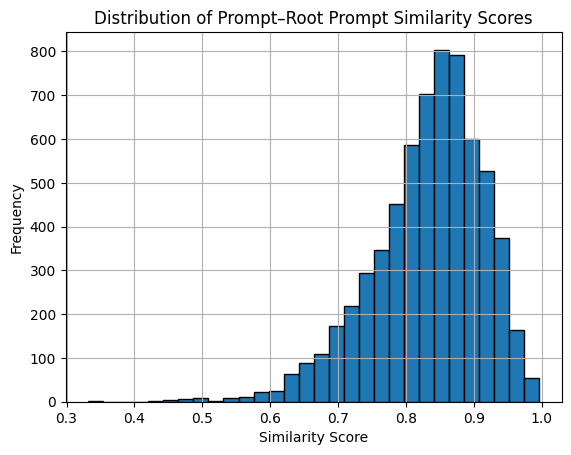

In [21]:
import matplotlib.pyplot as plt

plt.hist(sim_to_parentpop['batch_similarity'], bins=30, edgecolor='black')
plt.title('Distribution of Prompt–Root Prompt Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
